## Project: Chat with Any YouTube Video

The goal is to build a RAG-based chatbot that allows you to ask questions about a YouTube video without watching the entire video.

Example

Imagine there is a 3-hour podcast. Instead of watching all 3 hours, you can ask:

- "Is AI discussed in this video?"
- "Summarize the video in 5 points."
- "What did the speaker say about machine learning?"
- "Explain a concept mentioned at 1 hour into the video."

The system reads the video's content and answers your questions.

Overall RAG Architecture

The complete process has 4 main steps:

YouTube Video → Transcript → Chunks → Embeddings → Vector Store → Retrieve Relevant Information → LLM → Answer

## Step 1: Load the YouTube Transcript 📄

Every YouTube video may have a transcript, which is basically the text version of everything spoken in the video.

For example:

🎥 Video says:

"Machine learning is a subset of artificial intelligence..."

📄 Transcript becomes:

Machine learning is a subset of artificial intelligence...

So, the first step is:

YouTube Video ->  Fetch Transcript

The project uses the YouTube API to fetch the transcript.

## Step 2: Split the Transcript into Chunks ✂️

A transcript for a long video can be extremely large.

3-hour video -> 30,000+ words

We cannot efficiently send the entire transcript every time we ask a question. Therefore, we divide it into smaller pieces called chunks.

Example:

Complete Transcript

1. Chunk 1 → Introduction
2. Chunk 2 → AI Basics
3. Chunk 3 → Machine Learning
4. Chunk 4 → Deep Learning
5. Chunk 5 → Conclusion

This process is done using a Text Splitter.


## Step 3: Create Embeddings and Store Them 🧠

Computers cannot directly understand text like humans.

So we convert every chunk into numbers called embeddings.

For example:

Chunk: "Artificial Intelligence is transforming healthcare." -> Embedding Model -> [0.21, 0.45, -0.12, 0.78, ...]

These numbers represent the meaning of the sentence.

Then we store all these embeddings inside a Vector Store.

1. Chunk 1 → Vector
2. Chunk 2 → Vector
3. Chunk 3 → Vector
4. Chunk 4 → Vector.  ---> Vector Database

This completes the Indexing Phase of RAG.


## Step 4: Ask a Question 🔍

Suppose you ask:

"Does this video talk about AI?"

The system converts your question into an embedding.

Question -> Embedding

"Does this video talk about AI?" ->  [0.19, 0.42, -0.15, ...]

Then it searches the Vector Store for chunks with a similar meaning.

This is called Semantic Search.

Important

It does not necessarily search for exact words.

For example:

Question:
"Does the video discuss AI?"

Relevant Chunk:
"Artificial intelligence is changing modern technology."

Even though the sentences use different words, embeddings understand that their meaning is similar.

This step is called:

🔎 Retrieval

## Step 5: Augmentation 📝

Now we have:

The user's question
The relevant chunks from the video

We combine them into a prompt.

Example:

Context: Artificial intelligence is transforming healthcare, education, and manufacturing.

Question: Does this video discuss AI?

Answer:

This process of adding relevant information to the question is called:

Augmentation

## Step 6: Generation 🤖

Now we send the complete prompt to the LLM.

The LLM reads:

The user's question
The relevant information from the YouTube transcript

Then it generates an answer.

LLM -> "Yes, the video discusses AI and explains its applications in healthcare, education, and manufacturing."

This is called: Generation

In [2]:
!pip install -q youtube-transcript-api langchain-community langchain-google-genai \
faiss-cpu tiktoken python-dotenv

In [40]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_community.vectorstores import FAISS
from youtube_transcript_api import YouTubeTranscriptApi,TranscriptsDisabled
from langchain_huggingface import HuggingFaceEmbeddings
load_dotenv()

True

## Step 1 a - Indexing (Document Ingestion)

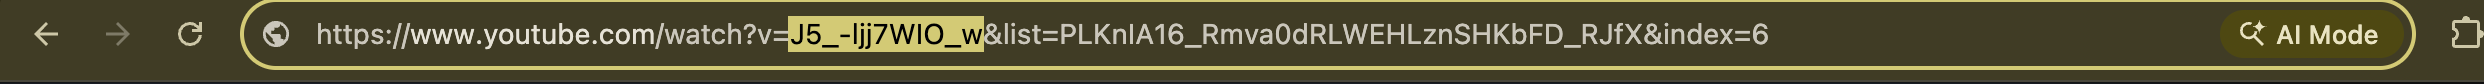

The video ID is the value after v= and before &:

In [17]:
from youtube_transcript_api import YouTubeTranscriptApi
from youtube_transcript_api._errors import (
    TranscriptsDisabled,
    VideoUnavailable,
    NoTranscriptFound
)

video_id = "l4NiLn3LIoM"

try:
    ytt_api = YouTubeTranscriptApi()

    transcript = ytt_api.fetch(
        video_id,
        languages=["en"]
    )

    print(transcript)

except VideoUnavailable:
    print("Video is unavailable or the video ID is incorrect.")

except TranscriptsDisabled:
    print("No captions available for this video.")

except NoTranscriptFound:
    print("No English transcript found for this video.")

FetchedTranscript(snippets=[FetchedTranscriptSnippet(text='If we win this, we go to nationals!', start=27.92, duration=2.0), FetchedTranscriptSnippet(text='Ichinan High School', start=29.5, duration=2.71), FetchedTranscriptSnippet(text='2nd\nYear', start=29.63, duration=2.58), FetchedTranscriptSnippet(text='National High School', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Soccer Championship', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Saitama Prefecture Finals', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Ichinan vs Matsukaze Kokuou', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Sponsors', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Saitama Soccer Organization', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Saitama High School Athletics Association', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='Saitama Broadcasting', start=32.21, duration=2.34), FetchedTranscriptSnippet(text='

In [22]:
for i in transcript:
    print(i) ## text- start and duration

FetchedTranscriptSnippet(text='If we win this, we go to nationals!', start=27.92, duration=2.0)
FetchedTranscriptSnippet(text='Ichinan High School', start=29.5, duration=2.71)
FetchedTranscriptSnippet(text='2nd\nYear', start=29.63, duration=2.58)
FetchedTranscriptSnippet(text='National High School', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Soccer Championship', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Saitama Prefecture Finals', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Ichinan vs Matsukaze Kokuou', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Sponsors', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Saitama Soccer Organization', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Saitama High School Athletics Association', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Saitama Broadcasting', start=32.21, duration=2.34)
FetchedTranscriptSnippet(text='Co-sponsors', start=32.21, duration=2.3

In [32]:
for chunk in transcript:
    print(chunk.text)

If we win this, we go to nationals!
Ichinan High School
2nd
Year
National High School
Soccer Championship
Saitama Prefecture Finals
Ichinan vs Matsukaze Kokuou
Sponsors
Saitama Soccer Organization
Saitama High School Athletics Association
Saitama Broadcasting
Co-sponsors
Sponsors
Co-sponsors
National High School
Soccer Championship
Saitama Prefecture Finals
Ichinan vs Matsukaze Kokuou
Saitama Soccer Organization
Saitama High School Athletics Association
Saitama Broadcasting
Ichinan
Matsukaze Kokuou
Go, Isagi!
This is our last chance! 
We're counting on you!
Nationals... Nationals... Nationals...
Nationals!
I'm over here, loser!
I'm gonna score.
Nationals!
Isagi!
Over here! I'm free!
Tada-chan?
If I pass, we'll score.
Isagi!
Remember, it's one 
for all and all for one!
That's right. Soccer's played 
with eleven guys on a team.
All right! Now we're tied—
No way!
Counter!
Push up!
Matsukaze Kokuou High School
2nd
Year
Crap!
Stop them!
Get through!
Ichinan
Matsukaze Kokuou
Sorry, guys!
If 

In [35]:
complete_transcript=" ".join([chunk.text for chunk in transcript])

## Step 1b- Text Splitter

In [36]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks=splitter.create_documents([complete_transcript])

In [38]:
len(chunks)

18

In [39]:
chunks[0]

Document(metadata={}, page_content="If we win this, we go to nationals! Ichinan High School 2nd\nYear National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Sponsors Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Co-sponsors Sponsors Co-sponsors National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Ichinan Matsukaze Kokuou Go, Isagi! This is our last chance! \nWe're counting on you! Nationals... Nationals... Nationals... Nationals! I'm over here, loser! I'm gonna score. Nationals! Isagi! Over here! I'm free! Tada-chan? If I pass, we'll score. Isagi! Remember, it's one \nfor all and all for one! That's right. Soccer's played \nwith eleven guys on a team. All right! Now we're tied— No way! Counter! Push up! Matsukaze Kokuou High School 2nd")

## step 1c and 1d - indexing (Embedding generation and vector store creation)

In [41]:
embedding_model=HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vector_store=FAISS.from_documents(embedding=embedding_model,documents=chunks)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [43]:
vector_store.index_to_docstore_id ## id generation for each chunk

{0: '15e5a06d-9877-415b-94c2-614568904422',
 1: 'bcbefc74-60db-45ec-88ab-7301c28dad58',
 2: '125781e4-d5f7-4b49-a891-070435e4ece0',
 3: '1818f528-964f-4be2-8631-c7aa97382a1c',
 4: '5ca506f8-3600-4779-b005-c49e0af5551a',
 5: '5afe7ac2-c35d-4409-ac9a-20c59ed0f169',
 6: 'a5f9af89-1551-403b-8824-9711c35002e6',
 7: '29a76fc0-d78e-478a-842b-009f3dce113f',
 8: '628e327f-3bd1-49f8-9b3e-4ad76e762fae',
 9: '990f1564-9be6-4213-8590-cd5c23f6a51a',
 10: '3eecdd63-e0d2-4873-8b14-cc2ce79420ee',
 11: '5b9cbf49-4ad7-4978-8319-01d43c31274e',
 12: '1fccf993-1a91-4ba0-b40f-7180e8bf5760',
 13: 'da6c2b32-0e59-4d5d-939e-49fe0a110e02',
 14: '5e1709a9-cc9b-42ac-a0db-e647768c4056',
 15: 'f2362754-f81e-45b2-9c37-f6d6d0d626d6',
 16: 'c3498135-49c9-412b-b3c7-c91216518d9c',
 17: '8880b138-0c72-4ab5-a91f-0a7451c70a36'}

In [47]:
vector_store.get_by_ids(['8880b138-0c72-4ab5-a91f-0a7451c70a36'])

[Document(id='8880b138-0c72-4ab5-a91f-0a7451c70a36', metadata={}, page_content="stopped crying, you'd fall asleep, and when you woke up, \nyou didn't remember a thing. And you used to forget to do\nyour homework all the time. That's why his grades\nweren't very good, right? Yup, you were very lucky\n you got picked, Yoichi. Isn't he just? Wait, were you dissing me at the end there?")]

## Step 2- Retrieval

In [48]:
retriever = vector_store.as_retriever(search_type='similarity',search_kwargs={'k':4})
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x347afbe00>, search_kwargs={'k': 4})

In [49]:
retriever.invoke('Who won the match?')

[Document(id='15e5a06d-9877-415b-94c2-614568904422', metadata={}, page_content="If we win this, we go to nationals! Ichinan High School 2nd\nYear National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Sponsors Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Co-sponsors Sponsors Co-sponsors National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Ichinan Matsukaze Kokuou Go, Isagi! This is our last chance! \nWe're counting on you! Nationals... Nationals... Nationals... Nationals! I'm over here, loser! I'm gonna score. Nationals! Isagi! Over here! I'm free! Tada-chan? If I pass, we'll score. Isagi! Remember, it's one \nfor all and all for one! That's right. Soccer's played \nwith eleven guys on a team. All right! Now we're tied— No way! Counter! Push up! Matsukaze Kokuou High Sch

## Step 3 - Augmentation

In [71]:
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

template=PromptTemplate(
    template='''
You are a helpful assistant.
Answer ONLY from the provided transcript context. 

{context}

Question:{question}
''',
input_variables=['context','question']
)

In [72]:
question="Which school anime talks about ?"
retrieved_docs=retriever.invoke(question)

In [73]:
retrieved_docs

[Document(id='15e5a06d-9877-415b-94c2-614568904422', metadata={}, page_content="If we win this, we go to nationals! Ichinan High School 2nd\nYear National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Sponsors Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Co-sponsors Sponsors Co-sponsors National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Ichinan Matsukaze Kokuou Go, Isagi! This is our last chance! \nWe're counting on you! Nationals... Nationals... Nationals... Nationals! I'm over here, loser! I'm gonna score. Nationals! Isagi! Over here! I'm free! Tada-chan? If I pass, we'll score. Isagi! Remember, it's one \nfor all and all for one! That's right. Soccer's played \nwith eleven guys on a team. All right! Now we're tied— No way! Counter! Push up! Matsukaze Kokuou High Sch

In [74]:
context_text="\n\n".join(doc.page_content for doc in retrieved_docs)

In [75]:
prompt=template.invoke({'context':context_text,'question':question})

In [76]:
prompt

StringPromptValue(text='\nYou are a helpful assistant.\nAnswer ONLY from the provided transcript context. \n\nIf we win this, we go to nationals! Ichinan High School 2nd\nYear National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Sponsors Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Co-sponsors Sponsors Co-sponsors National High School Soccer Championship Saitama Prefecture Finals Ichinan vs Matsukaze Kokuou Saitama Soccer Organization Saitama High School Athletics Association Saitama Broadcasting Ichinan Matsukaze Kokuou Go, Isagi! This is our last chance! \nWe\'re counting on you! Nationals... Nationals... Nationals... Nationals! I\'m over here, loser! I\'m gonna score. Nationals! Isagi! Over here! I\'m free! Tada-chan? If I pass, we\'ll score. Isagi! Remember, it\'s one \nfor all and all for one! That\'s right. Soccer\'s played \nwith eleven guys on a team. All right! Now we\'re tied— No way! Coun

## Step 4- Generation

In [77]:
answer=model.invoke(prompt)
print(answer.content)

[{'type': 'text', 'text': 'Based on the provided transcript, the following schools are mentioned:\n\n* **Ichinan High School**\n* **Matsukaze Kokuou High School**\n* **Sennou**', 'extras': {'signature': 'Eo4KCosKARFNMg+FKlVuYlBbGzEFiL6tNPIwiGY+AJMueu2W33uqsGgqlb5AWWpzJG5bENbrUXqO9zk9n2+ySMLZAoq1noFa1oquWFFRjNXAz4l2lgQwVBi10KhZthH1BjhsnqeoxQOILntswdAmtrMRLQQ3QY7wW41uCCP9/zxTtZrjEbxXGygQCdFTFACdfa4nyo9bXdHL5T390EEzS2+tFEgDg1UmfbMBcsDBYLrOLNCr61skJmF6QKi7fCSYq6qkObul+J/b6kmVwRpwWirPJNjGRlGpjY+LuhM4dJQJhDeplWvHEuKCxn5/4Mi81Ni5Ty7USXViP2u/Q+2WTzOhCrhCiiUp1caH9UwUE1umIlapXqHHmLibB2YgYJ9evzCf2H308ErBj8zw7iRdaOonYwvA/Kmso6Qn/F2bBViKysBvREhTG7p/O60+F74n6dTQrujhsNQxysqH6V32PCEe5xSV6QlJ59IajaGmCokjA2PvKUMYzez7WV24CqnI0FVKAmWa+ZtnXlc9dYJDugSTQRwGUk/W6jEVEWU9UDWCxYDJ7/O6Zq+7XeQH4HoRAhrKkNFaXLPjlRdcFwpJHBGWblN19vSlIq283Va5cV8QPpjXd94DyMoFhxtWBj+nzc8aS6XywpP7TqC1L943yU00Um9Jpkg8ZCHL4eD8rgjI3LUn4EKsgR7x3o+UrU7IpX5oAaXoG5Rg33z79VBc9xC1MCnRGWIbiVYZcdVP+IAlKZfxlHSNkirBRt57Y9YS69MFJbvp38yu0Gr52kQQAoXwGG9D

In [82]:
answer.content[0]['text']

'Based on the provided transcript, the following schools are mentioned:\n\n* **Ichinan High School**\n* **Matsukaze Kokuou High School**\n* **Sennou**'

## Building a chain

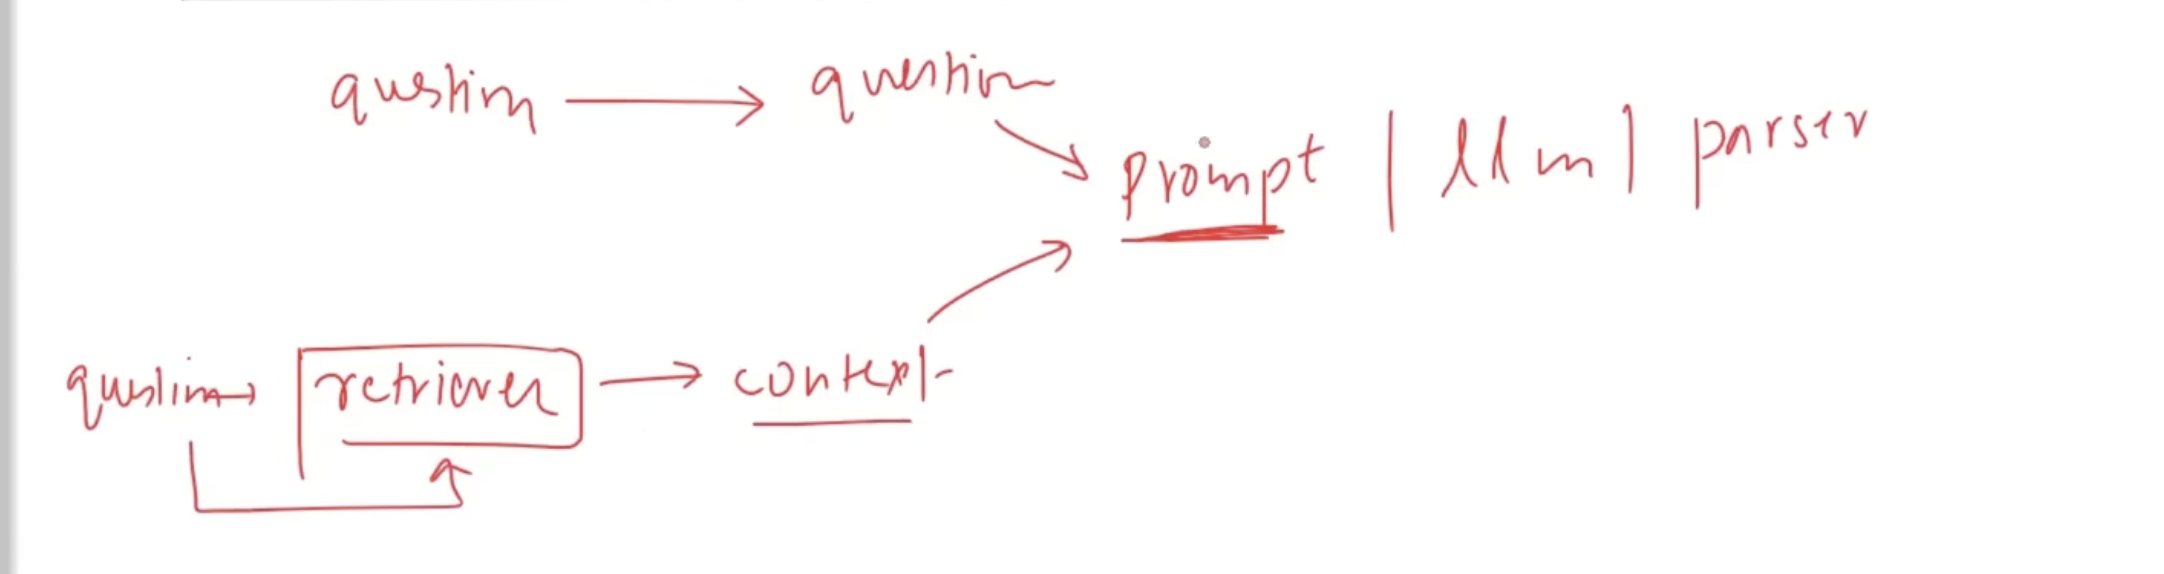

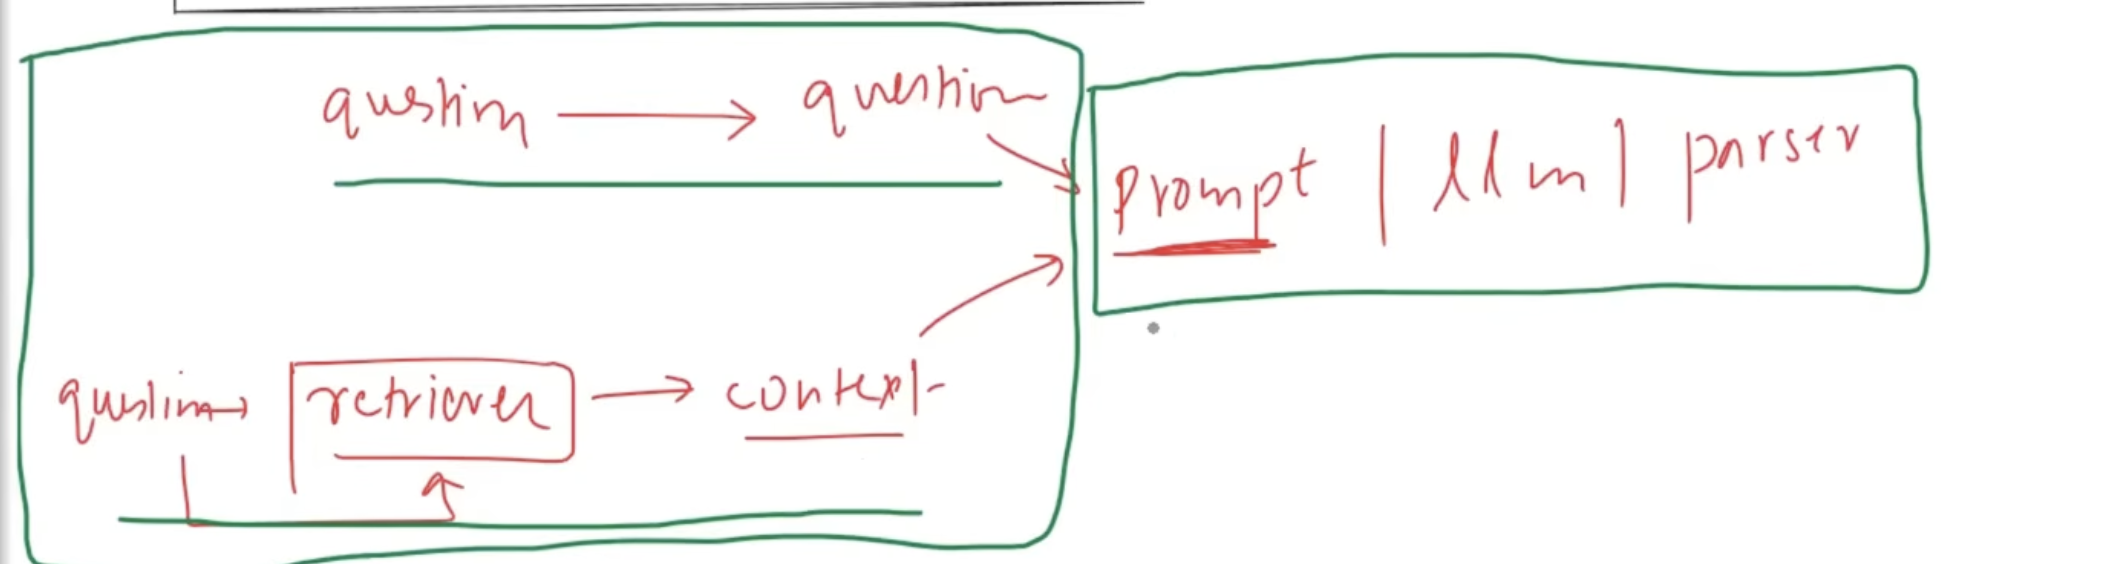

In [87]:
from langchain_classic.schema.runnable import RunnableSequence,RunnableParallel,RunnableLambda,RunnablePassthrough,RunnableBranch
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

In [84]:
def format_docs(retrieved_docs):
    context_text="\n\n".join(doc.page_content for doc in retrieved_docs)
    return context_text

In [93]:
parallel_chain=RunnableParallel(
    {
        'question': RunnablePassthrough(),
        'context':  RunnableSequence(retriever, RunnableLambda(format_docs))
    }
)

main_chain = RunnableSequence(parallel_chain,template,model,parser)


In [92]:
parallel_chain.invoke('Who is Yoichi Isagi?')

{'question': 'Who is Yoichi Isagi?',
 'context': 'defenders, and midfielders," "but strikers are different." "A first-rate striker will find \nwhere the soccer is most intense..." The strongest guy... Boom! "and suddenly appear there." Episode 1 Dream A Additional Time! Additional Time! Additional Time! Additional Time! Additional Time! Additional Time! Additional Time! m 0 0 l 100 0 100 100 0 100 Blue Lock m 0 0 l 100 0 100 100 0 100 Blue Lock m 0 0 l 100 0 100 100 0 100 Blue Lock m 0 0 l 100 0 100 100 0 100 Blue Lock m 0 0 l 100 0 100 100 0 100 Blue Lock Additional Time! m 0 0 l 100 0 100 100 0 100 Blue Lock Additional Time! Isagi Yoichi\'s Dream Isagi Yoichi\'s Dream Your mom and I don\'t \nknow much about soccer, Isagi Issei Isagi Issei but it\'s impressive that you \ngot chosen by the JFU, Yoichi. Isagi Iyo Isagi Iyo Isn\'t it just? But then, you\'ve always been\n\nknow much about soccer, Isagi Issei Isagi Issei but it\'s impressive that you \ngot chosen by the JFU, Yoichi. Isagi 

In [95]:
text=main_chain.invoke('Who is Yoichi Isagi?')

In [97]:
print(text)

Based on the provided transcript, Yoichi Isagi is a soccer player (a 2nd-year student at Ichinan High School) who was chosen by the JFU. 

According to his parents, he:
* Has been good at soccer since he was little.
* Always dreamed of becoming the world's greatest striker.
* Once asked Santa Claus for the World Cup trophy for Christmas.
* Was glued to the TV whenever a soccer game was on as a child and used to forget to do his homework all the time.


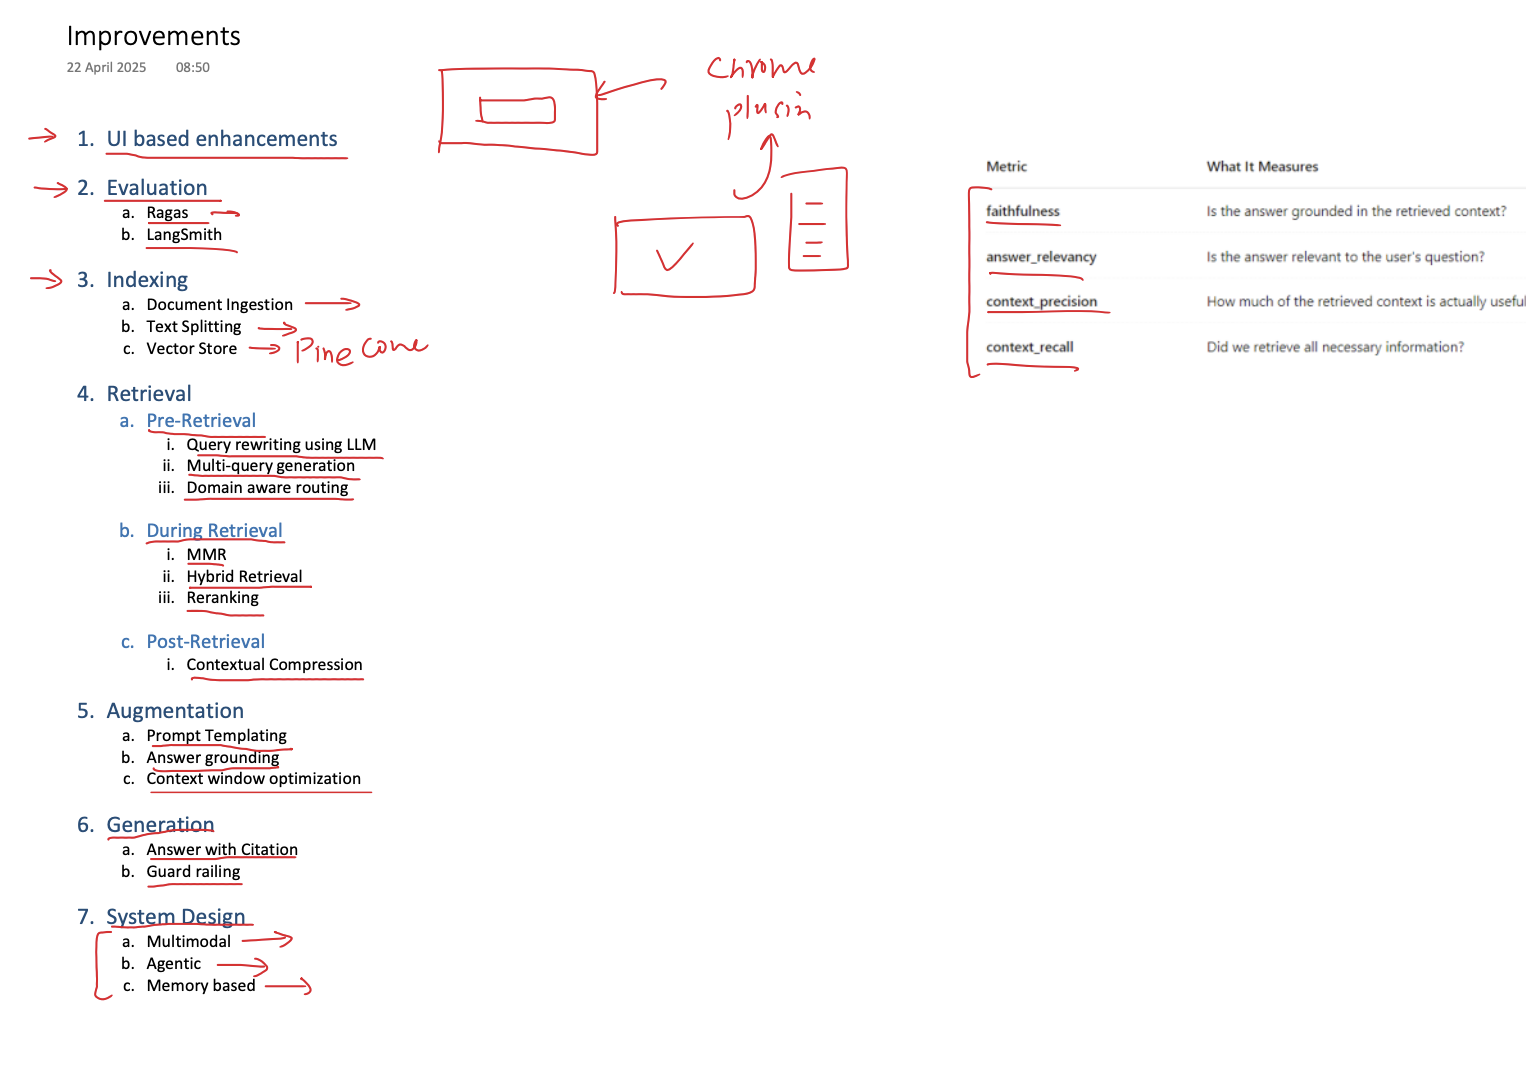

This transcript is explaining how to improve a simple RAG system into an industry-grade RAG system.

The main idea is:

The basic RAG system works, but real-world RAG applications need many additional techniques to make them more accurate, efficient, reliable, and usable.

Let's understand it in easy words.

##  What is the current simple RAG system?

Your YouTube chatbot currently works like this:


In [98]:
# YouTube Video
#       ↓
# Transcript
#       ↓
# Text Splitting
#       ↓
# Embeddings
#       ↓
# Vector Store
#       ↓
# Retriever
#       ↓
# Relevant Chunks
#       ↓
# Prompt
#       ↓
# LLM
#       ↓
# Answer

# every stage can be improved.

## 1️⃣ UI Improvements

Currently, the RAG system is running inside a notebook.

The user has to:

- Manually enter the video ID.
- Run multiple cells.
- Ask questions.

This is not a proper final product.

Better Option 1: Streamlit Website

You can create a website like:

In [ ]:
# ┌─────────────────────────────┐
# │ Paste YouTube URL           │
# │ [_______________________]   │
# │                             │
# │        [Submit]             │
# └─────────────────────────────┘

#         ↓

# ┌─────────────────────────────┐
# │ 🤖 Chat with Video          │
# │                             │
# │ You: Summarize the video    │
# │                             │
# │ AI: Here is the summary...  │
# └─────────────────────────────┘


# The user simply pastes a YouTube URL and starts chatting.


In [ ]:

# Better Option 2: Chrome Extension

# A more advanced product could be a Chrome extension.

# While watching YouTube:

# YouTube Video              Chat
# ┌──────────────┐      ┌───────────┐
# │              │      │ Ask me    │
# │   VIDEO      │      │ anything  │
# │              │      │ about the │
# │              │      │ video     │
# └──────────────┘      └───────────┘

# This makes the RAG system much more usable.



## 2️⃣ RAG Evaluation

A very important question is:

How do we know whether our RAG system is actually giving good answers? Just building the system is not enough. We need to measure its performance.

Tools such as RAGAS and LangSmith for evaluation and tracing.

Important Evaluation Metrics

***Faithfulness***

Question: Is the answer actually based on the retrieved context?

Example:

Context: The video discusses Python and machine learning.

Good answer: The video discusses Python and machine learning.

Bad answer: The video discusses quantum computing.

The second answer is a hallucination.

***Answer Relevance***

Question: What is machine learning?

Answer: Machine learning allows computers to learn patterns from data. ✅ Relevant.

But if the answer is: Python was created by Guido van Rossum. ❌ Not relevant to the question.

***Context Precision***

Question: Did the retriever retrieve useful documents?

For example:

Question: Explain neural networks

Retrieved chunks:

1. Chunk 1 → Neural networks explanation ✅
2. Chunk 2 → Deep learning explanation ✅
3. Chunk 3 → Cooking recipe ❌

The more irrelevant chunks you retrieve, the lower your precision.

***Context Recall***

Question: Did we retrieve all the important information required to answer the question?

Imagine there are five useful chunks in the database but the retriever only retrieves two. Then the system has poor context recall.

## 3️⃣ Improvements During Indexing


In [ ]:
# Indexing is:

# Document
#    ↓
# Split
#    ↓
# Embed
#    ↓
# Store in Vector Database

# There are many possible improvements here.


# A. Clean the Transcript

YouTube transcripts can contain errors.

For example:

Original speech: "I am learning Retrieval Augmented Generation."

Bad transcript: I am learning Retrieval Argument Generation.

You can preprocess and clean these errors before storing the transcript.

# B. Translate the Transcript

Suppose your video is in Hindi: मशीन लर्निंग डेटा से पैटर्न सीखती है।

You could translate it into English before indexing: Machine learning learns patterns from data.

This can be useful depending on your embedding model and the languages your application supports.

# C. Better Chunking

Currently, a basic system may use: RecursiveCharacterTextSplitter

The problem is that it might split text in the middle of a meaningful idea.

Example:

Chunk 1: Machine learning is a field where computers...

Chunk 2: ...learn patterns from data.

The sentence is divided. A possible improvement is Semantic Chunking, where chunks are divided according to meaning rather than just character limits.

# D. Better Vector Database

For learning, you may use:

FAISS

But in a production application, you may want a cloud-based vector database.

The transcript gives Pinecone as an example of a production-oriented alternative.



## 4️⃣ Pre-Retrieval Improvements

Before searching the vector database, you can improve the user's question.

Suppose the user asks:

What about that thing he said? This is vague.

An LLM could rewrite it into something clearer:

What did the speaker say about artificial intelligence?

Then retrieval becomes better.

***Multi-Query Generation***

One user query can be converted into multiple queries.

Original:

How does AI work?

Generated queries:

1. How does artificial intelligence work?
2. What are the principles behind AI?
3. How do AI systems process information?

Then you retrieve documents for multiple perspectives.

This improves the chance of finding relevant information.



# 5️⃣ Retrieval Improvements

The basic system uses:

***Similarity Search***

But more advanced methods exist.

1. MMR Search

MMR tries to retrieve:  Relevant documents + Diverse documents

Instead of retrieving five chunks that all say almost exactly the same thing.

2. Hybrid Search

Combine: Semantic Search + Keyword Search -> Better Retrieval and Semantic Search

Sementic: Understands meaning.

Keyword Search: Matches important words.

Using both can improve results.



3. Re-Ranking

Suppose retrieval returns:

- Document A → Score 0.91
- Document B → Score 0.88
- Document C → Score 0.85

A re-ranking model or LLM can analyze the documents again and decide:

- Document B → Most useful
- Document A → Second
- Document C → Third

So the best information reaches the LLM.

## 6️⃣ Post-Retrieval: Contextual Compression

Sometimes retrieved documents are huge.

Example:

Retrieved Chunk: Machine learning is a field of AI. It has many applications. There are supervised learning, unsupervised learning... hundreds of words...

But perhaps only one sentence answers the question.

Contextual compression keeps: Machine learning is a field of AI that learns patterns from data.

And removes unnecessary information.

Benefits: Less tokens -> Lower Cost -> faster response -> more focused prompt

## 7️⃣ Augmentation Improvements

Augmentation means:

User Question + Retrieved Context -> Prompt 

You need to design the prompt properly.

Example: 

You are a helpful assistant. Answer the user's question using ONLY the
provided context.

If the answer is not present in the context, say that the information is not available.

Context:{context}

Question:{question}

This is called prompt templating.

***Answer Grounding***

You explicitly tell the LLM:

"Do not create information yourself. Answer only using the provided context."

This reduces hallucinations.

## 8️⃣ Context Window Optimization

LLMs have a limit on how much text they can process at once.

Suppose you retrieve too much:

- Chunk 1 → 2,000 tokens
- Chunk 2 → 2,000 tokens
- Chunk 3 → 2,000 tokens
- Chunk 4 → 2,000 tokens

The context may become unnecessarily large.

So you trim the context:

In [ ]:

# Retrieved Context
#        ↓
# Remove unnecessary parts
#        ↓
# Keep important information
#        ↓
# Send to LLM

# This is called Context Window Optimization.


## 9️⃣ Generation Improvements

The final step is where the LLM generates an answer.

Two important improvements mentioned are: 

1. Answer with Citations

Instead of only saying: "Machine learning was discussed."

The system could say: "Machine learning was discussed in the section where the speaker explains AI applications."

This helps users know where the information came from.

2. Guardrails

Guardrails prevent the LLM from producing inappropriate or unreliable output.



In [ ]:
# For example:

# User Input
#      ↓
# Safety / Validation
#      ↓
#    LLM
#      ↓
# Output Validation
#      ↓
# Final Answer
# The goal is to prevent incorrect or undesirable responses.


## 🔟 Different Types of Advanced RAG

The transcript finally introduces more advanced RAG architectures.

1. Multimodal RAG

Normal RAG: Text → Text

Multimodal RAG:

- Text
- Image
- Video
- Audio
   
Creates RAG System

For example, you could ask about an image inside a PDF.

2. Agentic RAG

Normal RAG: Question -> Retrieve Context -> Answer


In [ ]:
# Agentic RAG:

# Question
#    ↓
# Agent decides what to do
#    ↓
# Retrieve Documents
#    ↓
# Maybe search the web
#    ↓
# Maybe call another tool
#    ↓
# Combine information
#    ↓
# Answer

# The RAG system behaves more like an AI agent.

3. Memory-Based RAG

The system remembers previous interactions.

Example:

Monday: You: Explain embeddings.

Friday: You: Explain that topic again.

The system remembers what you discussed earlier and can use that conversation context. This allows for more personalized applications.

## 🗺️ Complete Picture of Advanced RAG


In [ ]:
#                        SIMPLE RAG
#                              │
#         ┌────────────────────┼────────────────────┐
#         │                    │                    │
#      INDEXING            RETRIEVAL          AUGMENTATION
#         │                    │                    │
#    Clean Data          Query Rewrite       Prompt Templates
#    Translation         Multi Query         Answer Grounding
#    Semantic Chunking   Hybrid Search       Context Optimization
#    Better Vector DB    MMR
#                        Re-ranking
#                        Compression
#         │                    │                    │
#         └────────────────────┼────────────────────┘
#                              │
#                          GENERATION
#                              │
#                    ┌─────────┴─────────┐
#                    │                   │
#                 Citations          Guardrails
#                              │
#                              ▼
#                        ADVANCED RAG
#                              │
#           ┌──────────────────┼──────────────────┐
#           │                  │                  │
#      Multimodal RAG     Agentic RAG       Memory RAG

In [ ]:
          
# 🎯 The main takeaway

# The RAG system you are currently building for your YouTube chatbot is a basic RAG system.

# The transcript is telling you that:

# Basic RAG is only the starting point. Production-level RAG systems improve every stage—data ingestion, indexing, retrieval, augmentation, generation, evaluation, and user experience.

# For your current project, you should first complete the simple pipeline:

# YouTube Transcript
#       ↓
# Text Splitter
#       ↓
# Embeddings
#       ↓
# FAISS
#       ↓
# Retriever
#       ↓
# ChatGoogleGenerativeAI
#       ↓
# Answer

# Once this works, techniques such as semantic chunking, hybrid search, query rewriting, reranking, contextual compression, and evaluation can gradually turn it into a much stronger project.